# Face Detection with Haar Cascades

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
%matplotlib inline

## Images

In [2]:
with_out_glass =cv2.imread("E:\Digital Image\Project-without_glass.png",0)
with_glass = cv2.imread("E:\Digital Image\Project-with_glass.png",0)
group_photo = cv2.imread("E:\Digital Image\Project_group.png",0)

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Keerthivasan K S\AppData\Local\Temp\ipykernel_21152\2933689236.py:4: SyntaxWarning: invalid escape sequence '\D'
  with_out_glass =cv2.imread("E:\Digital Image\Project-without_glass.png",0)
C:\Users\Keerthivasan K S\AppData\Local\Temp\ipykernel_21152\2933689236.py:5: SyntaxWarning: invalid escape sequence '\D'
  with_glass = cv2.imread("E:\Digital Image\Project-with_glass.png",0)
C:\Users\Keerthivasan K S\AppData\Local\Temp\ipykernel_21152\2933689236.py:7: SyntaxWarning: invalid escape sequence '\D'
  group_photo = cv2.imread("E:\Digital Image\Project_group.png",0)


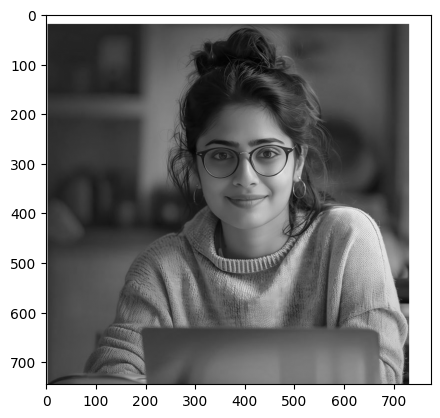

In [3]:
plt.imshow(with_glass,cmap='gray')

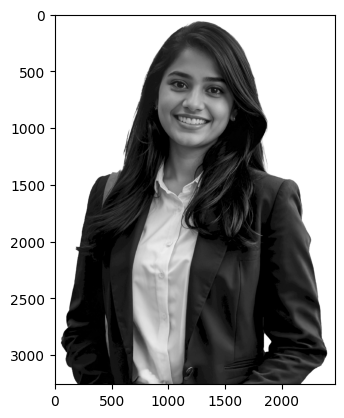

In [4]:
plt.imshow(with_out_glass,cmap='gray')

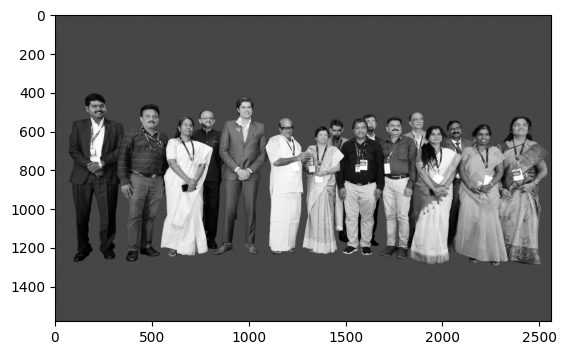

In [5]:
plt.imshow(group_photo,cmap='gray')

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [6]:
face_cascade = cv2.CascadeClassifier("E:\Digital Image\haarcascade_frontalface_default.xml")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Keerthivasan K S\AppData\Local\Temp\ipykernel_21152\1324998167.py:1: SyntaxWarning: invalid escape sequence '\D'
  face_cascade = cv2.CascadeClassifier("E:\Digital Image\haarcascade_frontalface_default.xml")


## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [7]:
def detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2) 
        
    return face_img


In [8]:
result = detect_face(with_glass)

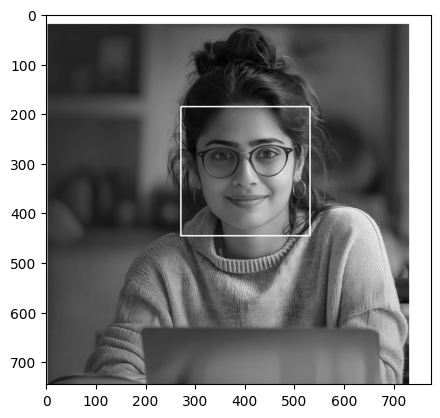

In [9]:
plt.imshow(result,cmap='gray')

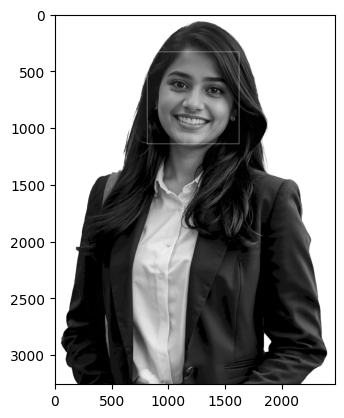

In [10]:
result = detect_face(with_out_glass)
plt.imshow(result,cmap='gray')

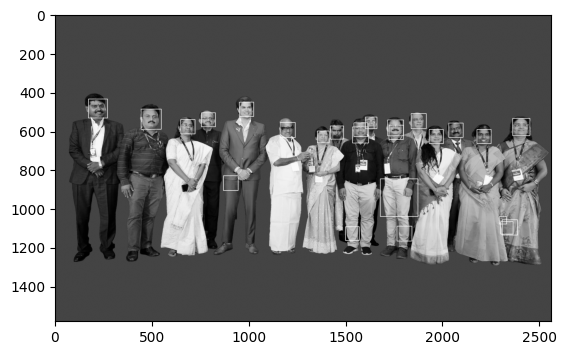

In [11]:
# Gets errors!
result = detect_face(group_photo)
plt.imshow(result,cmap='gray')

In [12]:
def adj_detect_face(img):
    
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2, minNeighbors=5) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2) 
        
    return face_img

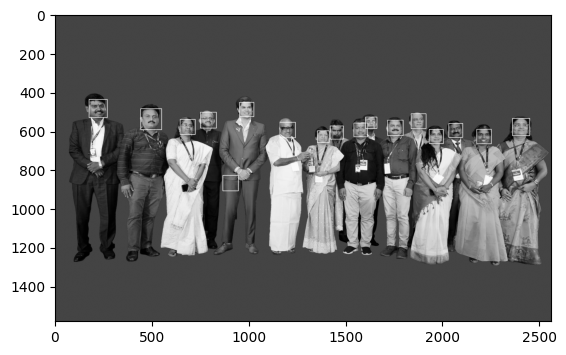

In [13]:
# Doesn't detect the side face.
result = adj_detect_face(group_photo)
plt.imshow(result,cmap='gray')

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [14]:
eye_cascade = cv2.CascadeClassifier("E:\Digital Image\haarcascade_eye.xml")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Keerthivasan K S\AppData\Local\Temp\ipykernel_21152\1189514157.py:1: SyntaxWarning: invalid escape sequence '\D'
  eye_cascade = cv2.CascadeClassifier("E:\Digital Image\haarcascade_eye.xml")


In [15]:
def detect_eyes(img):
    
    face_img = img.copy()
  
    eyes = eye_cascade.detectMultiScale(face_img) 
    
    
    for (x,y,w,h) in eyes: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 2) 
        
    return face_img

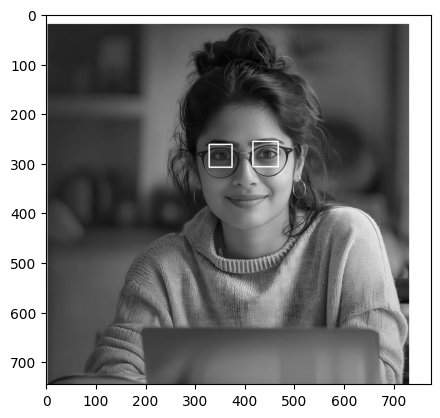

In [16]:
result = detect_eyes(with_glass)
plt.imshow(result,cmap='gray')

In [17]:
eyes = eye_cascade.detectMultiScale(with_out_glass) 

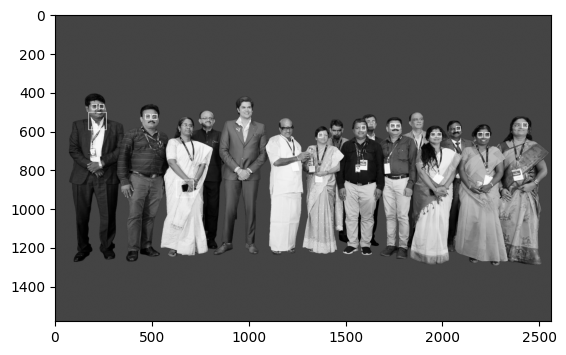

In [18]:
# White around the pupils is not distinct enough to detect eyes here!
result = detect_eyes(group_photo)
plt.imshow(result,cmap='gray')